<a href="https://colab.research.google.com/github/Sree1517/HANGMAN/blob/main/LanguageDetector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Install and import


In [ ]:
import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:

# Load the CSV file
df = pd.read_csv("dataLang.csv")
df = df[['code', 'language']]
df.head()

,code,language
0,"def hello_world():\n print('Hello, World!')...",Python
1,import numpy as np\nimport pandas as pd\n\ndef...,Python
2,"class Animal:\n def __init__(self, name, sp...",Python
3,def fibonacci(n):\n if n <= 1:\n ret...,Python
4,"with open('file.txt', 'r') as f:\n lines = ...",Python


#3.basic processing

In [ ]:
def preprocess_code(text):
    text = str(text)
    text = text.replace("\t", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df = df.dropna(subset=["code", "language"]).copy()
df["code"] = df["code"].apply(preprocess_code)

print(df.shape)
print(df["language"].value_counts())

(37, 2)
language
Python        8
JavaScript    8
Java          7
C             7
C++           7
Name: count, dtype: int64


Train test


In [ ]:
X = df["code"]
y = df["language"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 29
Testing samples: 8


#Build TF-IDF feature extractor
This version combines:

word n-grams

character n-grams

Using both is a good choice for code because syntax, operators, and short token patterns matter. A FeatureUnion is a known way to combine word and character TF-IDF features.

In [ ]:
word_tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    lowercase=False,
    min_df=1
)

char_tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    lowercase=False,
    min_df=1
)

tfidf_features = FeatureUnion([
    ("word_tfidf", word_tfidf),
    ("char_tfidf", char_tfidf)
])

Define models
Linear models and Naive Bayes are widely used baselines for sparse text features

In [ ]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Linear SVM": LinearSVC()
}

#Train and evaluate all models
Standard evaluation for text classification often includes accuracy, confusion matrix, and class-wise precision/recall/F1.

In [ ]:
results = {}
trained_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ("features", tfidf_features),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))

    results[model_name] = {
        "accuracy": acc,
        "classification_report": report,
        "confusion_matrix": cm
    }

    trained_pipelines[model_name] = pipeline

    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))


Model: Multinomial Naive Bayes
Accuracy: 1.0000
              precision    recall  f1-score   support

           C       1.00      1.00      1.00         1
         C++       1.00      1.00      1.00         1
        Java       1.00      1.00      1.00         2
  JavaScript       1.00      1.00      1.00         2
      Python       1.00      1.00      1.00         2

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8


Model: Logistic Regression
Accuracy: 1.0000
              precision    recall  f1-score   support

           C       1.00      1.00      1.00         1
         C++       1.00      1.00      1.00         1
        Java       1.00      1.00      1.00         2
  JavaScript       1.00      1.00      1.00         2
      Python       1.00      1.00      1.00         2

    accuracy                           1.00         8
   macro avg       1.00      1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

#Compare model performance


In [ ]:
comparison = []

for model_name, result in results.items():
    comparison.append({
        "Model": model_name,
        "Accuracy": result["accuracy"],
        "Precision (weighted)": result["classification_report"]["weighted avg"]["precision"],
        "Recall (weighted)": result["classification_report"]["weighted avg"]["recall"],
        "F1-score (weighted)": result["classification_report"]["weighted avg"]["f1-score"]
    })

comparison_df = pd.DataFrame(comparison).sort_values(by="Accuracy", ascending=False)
comparison_df

,Model,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted)
0,Multinomial Naive Bayes,1.000,1.000000,1.000,1.000
1,Logistic Regression,1.000,1.000000,1.000,1.000
2,Linear SVM,0.875,0.791667,0.875,0.825


#Plot confusion matrix for best model
Confusion matrices help show where the classifier confuses one class with another.

python

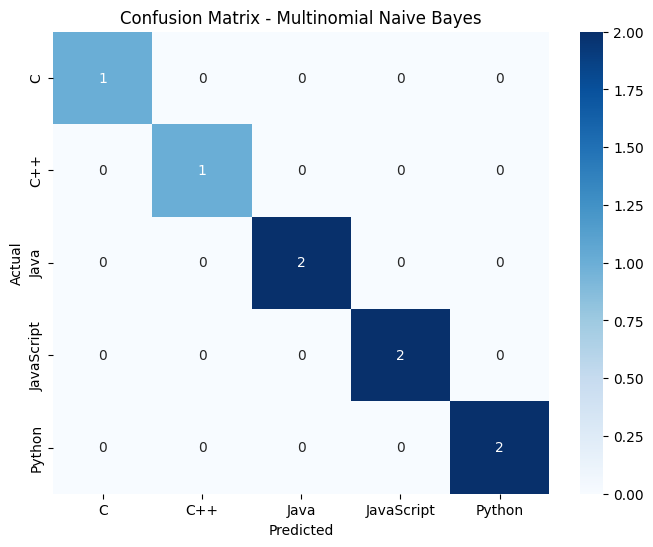

Best model: Multinomial Naive Bayes


In [ ]:
best_model_name = comparison_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]
best_cm = results[best_model_name]["confusion_matrix"]
labels = sorted(y.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

print("Best model:", best_model_name)

#Save the best model
Model persistence is useful for later prediction or web deployment.

In [ ]:
joblib.dump(best_pipeline, "best_code_language_detector.pkl")
print("Saved best model as best_code_language_detector.pkl")

Saved best model as best_code_language_detector.pkl


# Predict on new code snippets

In [ ]:
def predict_language(snippet, model):
    snippet = preprocess_code(snippet)
    prediction = model.predict([snippet])[0]
    return prediction
sample_code =input("Enter your code snippet here:\n")
predicted_lang = predict_language(sample_code, best_pipeline)
print("Predicted Language:", predicted_lang)

Enter your code snippet here:
hi
Predicted Language: C


#Test with multiple examples

In [ ]:
test_snippets = [
    "console.log('Hello'); let x = 5;",
    "#include <stdio.h>\nint main(){ return 0; }",
    "public static void main(String[] args) { System.out.println('Hi'); }",
    "def multiply(a, b): return a * b",
    "#include <iostream>\nusing namespace std;\ncout << 'Hello';"
]

for snippet in test_snippets:
    print("Code Snippet:", snippet)
    print("Predicted Language:", predict_language(snippet, best_pipeline))
    print("-" * 60)

Code Snippet: console.log('Hello'); let x = 5;
Predicted Language: JavaScript
------------------------------------------------------------
Code Snippet: #include <stdio.h>
int main(){ return 0; }
Predicted Language: C
------------------------------------------------------------
Code Snippet: public static void main(String[] args) { System.out.println('Hi'); }
Predicted Language: Java
------------------------------------------------------------
Code Snippet: def multiply(a, b): return a * b
Predicted Language: Python
------------------------------------------------------------
Code Snippet: #include <iostream>
using namespace std;
cout << 'Hello';
Predicted Language: C++
------------------------------------------------------------


#Probability scores with Logistic Regression

In [ ]:
logreg_pipeline = Pipeline([
    ("features", tfidf_features),
    ("classifier", LogisticRegression(max_iter=2000))
])

logreg_pipeline.fit(X_train, y_train)

snippet = "function greet(){ console.log('hello'); }"
probs = logreg_pipeline.predict_proba([preprocess_code(snippet)])[0]
classes = logreg_pipeline.named_steps["classifier"].classes_

prob_df = pd.DataFrame({
    "Language": classes,
    "Probability": probs
}).sort_values(by="Probability", ascending=False)

prob_df

,Language,Probability
3,JavaScript,0.440151
4,Python,0.168883
0,C,0.136806
1,C++,0.135076
2,Java,0.119084


In [ ]:
!pip install -q streamlit
!npm install -g localtunnel


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
changed 22 packages in 2s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏

In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import re

st.set_page_config(
    page_title="Code Language Detector",
    page_icon="💻",
    layout="centered"
)

@st.cache_resource
def load_model():
    return joblib.load("best_code_language_detector.pkl")

def preprocess_code(text):
    text = str(text)
    text = text.replace("\t", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

model = load_model()

st.title("💻 Code Language Detector")
st.write("Detect the programming language of a source code snippet using Machine Learning.")

st.markdown("---")

code_input = st.text_area(
    "Paste your code snippet here:",
    height=250,
    placeholder="Example:\ndef hello():\n    print('Hello World')"
)

if st.button("Predict Language"):
    if code_input.strip() == "":
        st.warning("Please enter a code snippet.")
    else:
        cleaned_code = preprocess_code(code_input)
        prediction = model.predict([cleaned_code])[0]
        st.success(f"Predicted Language: {prediction}")
        st.code(code_input)

st.markdown("---")
st.caption("Built in Google Colab using Streamlit + scikit-learn")

Overwriting app.py


In [ ]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 &>/content/logs.txt &

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3CtJReKWMka8JgIE8VTVSjvMAtc_3DYHeQoSj3TGXRqr95Yvv")
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://staging-breeder-mangle.ngrok-free.dev" -> "http://localhost:8501"
